In [12]:
# Task 1: Data Exploration
import pandas as pd

# Question 1: Load dataset and print first 5 rows
student_data = pd.read_csv("students.csv")

print("First 5 rows:\n")
print(student_data.head())


# Question 2: Print shape and data types
print("\nShape of dataset (rows, columns):")
print(student_data.shape)

print("\nData types:\n")
print(student_data.dtypes)


#Question 3: Summary statistics
print("\nSummary statistics:\n")
print(student_data.describe())


#Question 4: Count pass and fail students
print("\nPass and Fail count:\n")

count_result = student_data["passed"].value_counts()
print(count_result)


#Question 5: Average marks (Pass vs Fail)

subjects_list = ["math", "science", "english", "history", "pe"]

pass_group = student_data[student_data["passed"] == 1]
fail_group = student_data[student_data["passed"] == 0]

print("\nAverage marks of PASS students:\n")
print(pass_group[subjects_list].mean())

print("\nAverage marks of FAIL students:\n")
print(fail_group[subjects_list].mean())


# Question 6: Find top student (highest average)

student_data["average_marks"] = student_data[subjects_list].mean(axis=1)

max_avg_value = student_data["average_marks"].max()

topper_data = student_data[student_data["average_marks"] == max_avg_value]

print("\nTop Student:\n")
print(topper_data[["name", "average_marks"]])

First 5 rows:

      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Shape of dataset (rows, columns):
(15, 9)

Data types:

name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

Summary statistics:

            


--- BAR CHART: Average Score per Subject ---



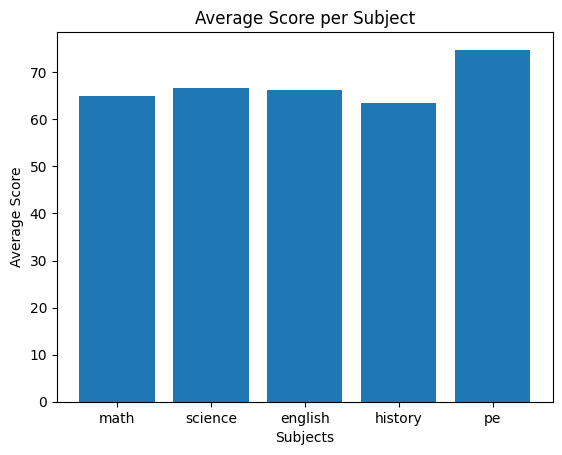


--- HISTOGRAM: Math Score Distribution ---



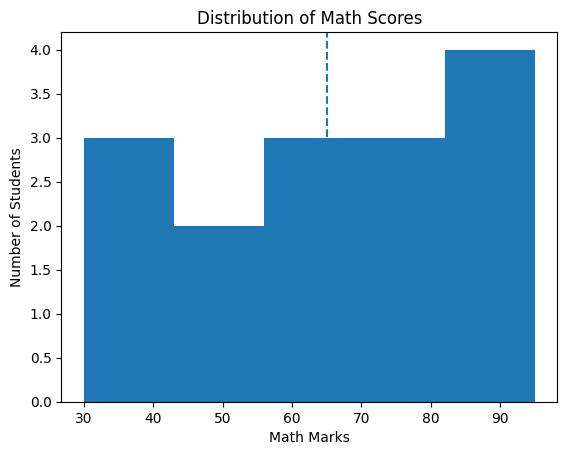


--- SCATTER PLOT: Study Hours vs Average Score ---



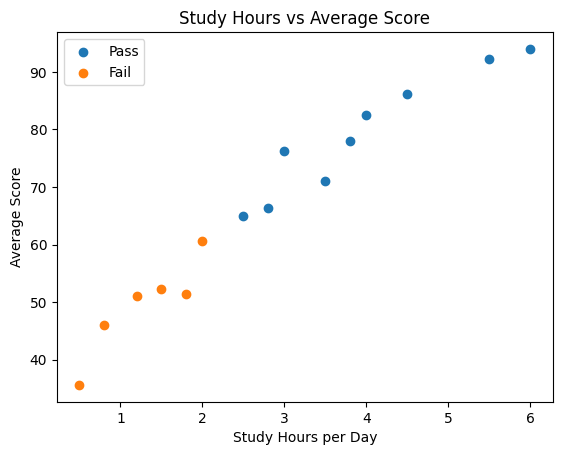


--- BOX PLOT: Attendance (Pass vs Fail) ---



/tmp/ipykernel_14226/2546920525.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_att, fail_att], labels=["Pass", "Fail"])


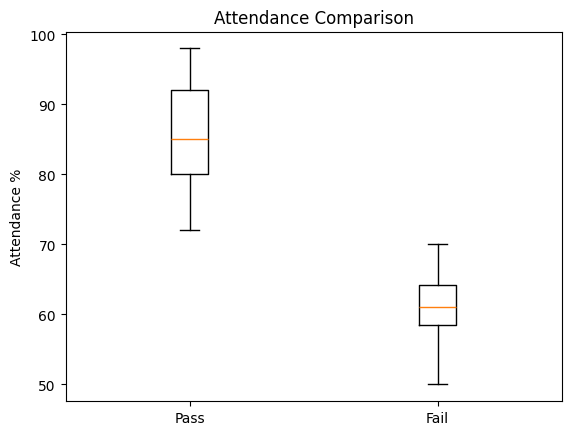


--- LINE PLOT: Math vs Science Scores ---



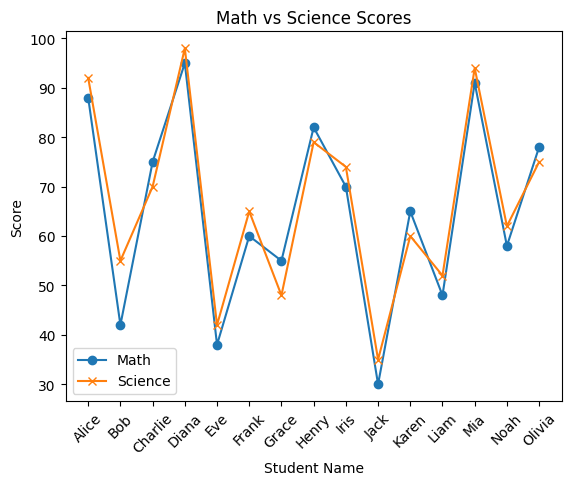

In [13]:
# Task 2: Data Visualization
import pandas as pd
import matplotlib.pyplot as plt


# Load dataset
df = pd.read_csv("students.csv")

# Create avg_score
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)


# Question 1: Bar Chart
print("\n--- BAR CHART: Average Score per Subject ---\n")

avg_values = df[subject_cols].mean()

plt.figure()
plt.bar(subject_cols, avg_values)

plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")

plt.savefig("plot1_bar.png")
plt.show()


# Question 2: Histogram
print("\n--- HISTOGRAM: Math Score Distribution ---\n")

math_marks = df['math']

plt.figure()
plt.hist(math_marks, bins=5)

mean_val = math_marks.mean()
plt.axvline(mean_val, linestyle='dashed')
plt.title("Distribution of Math Scores")
plt.xlabel("Math Marks")
plt.ylabel("Number of Students")
plt.savefig("plot2_hist.png")
plt.show()


# Question 3: Scatter Plot
print("\n--- SCATTER PLOT: Study Hours vs Average Score ---\n")

pass_data = df[df['passed'] == 1]
fail_data = df[df['passed'] == 0]

plt.figure()
plt.scatter(pass_data['study_hours_per_day'], pass_data['avg_score'], label="Pass")
plt.scatter(fail_data['study_hours_per_day'], fail_data['avg_score'], label="Fail")

plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()
plt.savefig("plot3_scatter.png")
plt.show()


#Question 4: Box Plot
print("\n--- BOX PLOT: Attendance (Pass vs Fail) ---\n")

pass_att = pass_data['attendance_pct'].tolist()
fail_att = fail_data['attendance_pct'].tolist()
plt.figure()
plt.boxplot([pass_att, fail_att], labels=["Pass", "Fail"])
plt.title("Attendance Comparison")
plt.ylabel("Attendance %")
plt.savefig("plot4_box.png")
plt.show()


#Question 5: Line Plot

print("\n--- LINE PLOT: Math vs Science Scores ---\n")
names_list = df['name']
plt.figure()
plt.plot(names_list, df['math'], marker='o', label="Math")
plt.plot(names_list, df['science'], marker='x', label="Science")
plt.title("Math vs Science Scores")
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()
plt.savefig("plot5_line.png")
plt.show()


SEABORN BAR PLOT: Math & Science (Pass vs Fail)



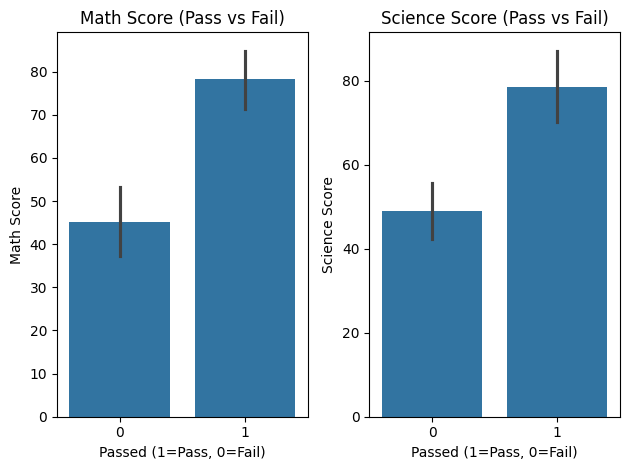


SEABORN SCATTER + REGRESSION



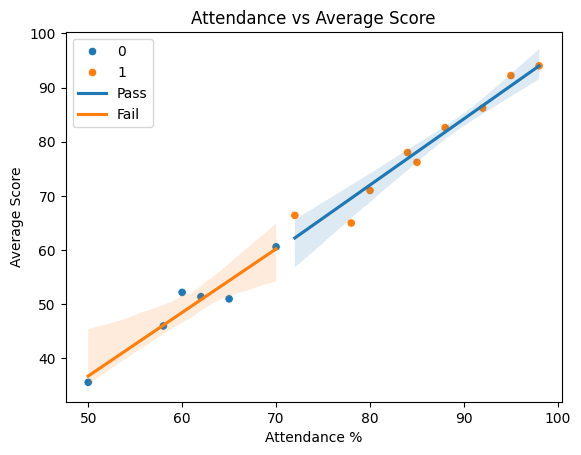

In [14]:
# Task 3: Data Visualization with Seaborn


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Load data
df = pd.read_csv("students.csv")

# Create avg_score
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

#Question 1: Seaborn Bar Plot
print("\nSEABORN BAR PLOT: Math & Science (Pass vs Fail)\n")

plt.figure()

# subplot 1 for math
plt.subplot(1, 2, 1)
sns.barplot(data=df, x='passed', y='math')
plt.title("Math Score (Pass vs Fail)")
plt.xlabel("Passed (1=Pass, 0=Fail)")
plt.ylabel("Math Score")

# subplot 2 for science
plt.subplot(1, 2, 2)
sns.barplot(data=df, x='passed', y='science')
plt.title("Science Score (Pass vs Fail)")
plt.xlabel("Passed (1=Pass, 0=Fail)")
plt.ylabel("Science Score")

plt.tight_layout()

plt.savefig("plot6_seaborn_bar.png")
plt.show()


#Question 2: Seaborn Scatter + Regression
print("\nSEABORN SCATTER + REGRESSION\n")

plt.figure()

# scatter points
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')

# regression line for PASS
sns.regplot(data=df[df['passed'] == 1],
            x='attendance_pct',
            y='avg_score',
            scatter=False,
            label='Pass')

# regression line for FAIL
sns.regplot(data=df[df['passed'] == 0],
            x='attendance_pct',
            y='avg_score',
            scatter=False,
            label='Fail')

plt.title("Attendance vs Average Score")
plt.xlabel("Attendance %")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("plot7_seaborn_scatter.png")
plt.show()


# Question 3: Comparison Comment

# Seaborn was easier to use because it automatically handles styling and grouping.
# In Matplotlib, we had to manually create separate plots and manage labels.
# Seaborn makes complex plots like grouped bar charts and regression lines much simpler.


 DATA PREPARATION


TRAINING MODEL

Training Accuracy: 1.0

TESTING MODEL

Test Accuracy: 1.0

Detailed Results:

Jack | Actual: 0 | Predicted: 0 | ✅ Correct
Liam | Actual: 0 | Predicted: 0 | ✅ Correct
Alice | Actual: 1 | Predicted: 1 | ✅ Correct

FEATURE IMPORTANCE

english : 0.8125127982724648
attendance_pct : 0.521876340433209
study_hours_per_day : 0.4844326627100155
pe : 0.47497406284967797
math : 0.43794393086873595
science : 0.3230097624690249
history : 0.26292892629062437


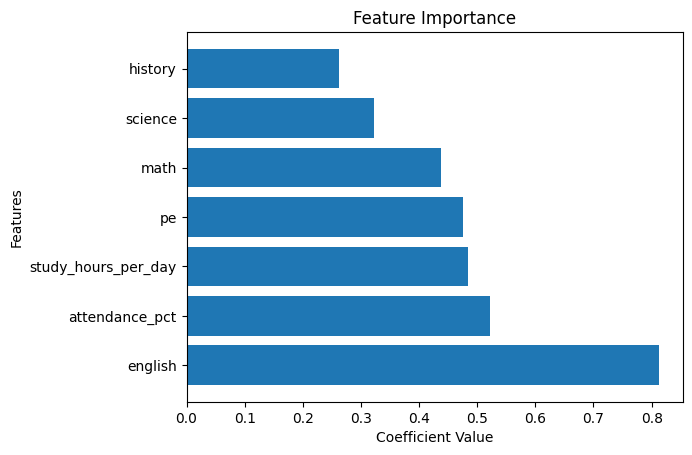


--- NEW STUDENT PREDICTION ---

Prediction: PASS
Probability: [[0.09203526 0.90796474]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [15]:
# Task 4: Machine Learning

import pandas as pd
import matplotlib.pyplot as plt

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

#  Load data
df = pd.read_csv("students.csv")


# Question 1: Prepare Data

print("\n DATA PREPARATION\n")

# features (X)
X = df[['math', 'science', 'english', 'history', 'pe',
        'attendance_pct', 'study_hours_per_day']]

# target (y)
y = df['passed']

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Question 2: Train Model

print("\nTRAINING MODEL\n")

model = LogisticRegression()

model.fit(X_train_scaled, y_train)

train_acc = model.score(X_train_scaled, y_train)

print("Training Accuracy:", train_acc)


#Question 3: Evaluate Model
print("\nTESTING MODEL\n")

predicted = model.predict(X_test_scaled)

test_acc = model.score(X_test_scaled, y_test)

print("Test Accuracy:", test_acc)

print("\nDetailed Results:\n")

# get names using index
test_names = df.loc[X_test.index, 'name']

for i in range(len(test_names)):
    name = test_names.iloc[i]
    actual = y_test.iloc[i]
    pred = predicted[i]

    if actual == pred:
        result = "✅ Correct"
    else:
        result = "❌ Wrong"

    print(name, "| Actual:", actual, "| Predicted:", pred, "|", result)


#Question 4: Feature Importance

print("\nFEATURE IMPORTANCE\n")

feature_names = X.columns
coeff_values = model.coef_[0]

# combine feature + value
feature_data = list(zip(feature_names, coeff_values))

# sort by importance
feature_data.sort(key=lambda x: abs(x[1]), reverse=True)

# print
for f_name, val in feature_data:
    print(f_name, ":", val)


# Plot feature importance

names = [x[0] for x in feature_data]
values = [x[1] for x in feature_data]

plt.figure()

colors = []
for v in values:
    if v > 0:
        colors.append("green")
    else:
        colors.append("red")

plt.barh(names, values)

plt.title("Feature Importance")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")

plt.savefig("plot8_feature_importance.png")
plt.show()


# Question 5: Predict New Student

print("\n--- NEW STUDENT PREDICTION ---\n")

new_student = [[75, 70, 68, 65, 80, 82, 3.2]]

# scale it
new_scaled = scaler.transform(new_student)

# predict
new_pred = model.predict(new_scaled)
prob = model.predict_proba(new_scaled)

if new_pred[0] == 1:
    print("Prediction: PASS")
else:
    print("Prediction: FAIL")

print("Probability:", prob)